<a href="https://colab.research.google.com/github/pavaid/Lung_anomaly_detectection_histopathology_lunghist700_reduction/blob/main/lunghist_7reduced_dataset_comparision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install torch torchvision timm scikit-learn albumentations optuna

import os, glob, random
import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import timm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 12.7 MB/s eta 0:00:00


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [ ]:
from google.colab import drive
drive.mount('/content/drive',force_remount=True)

Mounted at /content/drive


In [ ]:
# Path to dataset
data_dir = "/content/drive/MyDrive/SAM_enhanced"
labels_df = pd.read_csv("/content/drive/MyDrive/data.csv")

# Clean missing
labels_df = labels_df.dropna(subset=["superclass", "subclass", "image_id"]).reset_index(drop=True)

# Folder name = superclass_subclass
labels_df["folder"] = labels_df["superclass"] + "_" + labels_df["subclass"]

# Encode labels
le = LabelEncoder()
labels_df["label"] = le.fit_transform(labels_df["subclass"])
print("Classes:", le.classes_)

# Split dataset
train_df, temp_df = train_test_split(labels_df, test_size=0.3, stratify=labels_df["label"], random_state=42)
val_df, test_df   = train_test_split(temp_df, test_size=0.5, stratify=temp_df["label"], random_state=42)

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")


Classes: ['bd' 'md' 'pd']
Train: 378, Val: 81, Test: 81


In [ ]:
def preprocess_image(img_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.GaussianBlur(img, (5,5), 0)
    img = cv2.resize(img, (224,224))
    return img

augment = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Affine(scale=(0.9,1.1), translate_percent=(0.1,0.1),
             rotate=(-15,15), shear=(-5,5), p=0.5),
    A.RandomBrightnessContrast(p=0.5),
    A.GaussianBlur(blur_limit=(3,5), p=0.3),
    A.Normalize(mean=(0.485,0.456,0.406),
                std=(0.229,0.224,0.225)),
    ToTensorV2()
])


In [ ]:
def tile_image_for_mil(img_rgb, patch_size=224, stride=224, max_patches=64, mode="grid"):
    H, W = img_rgb.shape[:2]
    patches = []
    for y in range(0, max(1, H - patch_size + 1), stride):
        for x in range(0, max(1, W - patch_size + 1), stride):
            crop = img_rgb[y:y+patch_size, x:x+patch_size]
            if crop.shape[:2] == (patch_size, patch_size):
                patches.append(crop)
    if len(patches) > max_patches:
        idx = np.linspace(0, len(patches)-1, max_patches).astype(int)
        patches = [patches[i] for i in idx]
    if len(patches) == 0:
        patches = [cv2.resize(img_rgb, (patch_size, patch_size))]
    return patches

class MILBagDataset(Dataset):
    def __init__(self, img_root, df, augment, patch_size=224, stride=224, max_patches=32):
        self.img_root, self.df, self.augment = img_root, df.reset_index(drop=True), augment
        self.patch_size, self.stride, self.max_patches = patch_size, stride, max_patches

    def _resolve_img_path(self, row):

        folder = row["folder"]
        image_id = str(row["image_id"])

    # Multiple possible patterns
        patterns = [
        f"{folder}_20x_{image_id}_clahe*",
        f"{folder}_40x_{image_id}_clahe*",
        f"{folder}_20x_{image_id}*",
        f"{folder}_40x_{image_id}*",
        f"{folder}_{image_id}*",
        f"{image_id}*"
    ]

        for patt in patterns:
          files = glob.glob(os.path.join(self.img_root, folder, patt))
          if files:
            return files[0]

    # If nothing found, return None instead of crashing
        return None

    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
      row = self.df.iloc[idx]
      img_path = self._resolve_img_path(row)
      if img_path is None:
        raise FileNotFoundError(f"No file found for row: {row.to_dict()}")

      raw = cv2.imread(img_path)
      raw = cv2.cvtColor(raw, cv2.COLOR_BGR2RGB)
      raw = cv2.GaussianBlur(raw, (5,5), 0)

      patches = tile_image_for_mil(raw, patch_size=self.patch_size, stride=self.stride,
                                 max_patches=self.max_patches)
      tensor_patches = [self.augment(image=p)["image"] for p in patches]
      bag_tensor = torch.stack(tensor_patches, dim=0)
      return bag_tensor, int(row["label"]), row["image_id"]


def mil_collate(batch):
    bags, labels, ids = zip(*batch)
    return list(bags), torch.tensor(labels, dtype=torch.long), list(ids)


In [ ]:
class MILModel(nn.Module):
    def __init__(self, backbone, num_classes, agg="mean"):
        super().__init__()
        self.backbone = backbone
        self.classifier = nn.Linear(backbone.num_features, num_classes)
        self.agg = agg

    def forward(self, bag):
        if bag.dim() == 4:
            bag = bag.unsqueeze(0)
        B, n, C, H, W = bag.shape
        bag = bag.view(B*n, C, H, W)

        feats = self.backbone(bag)
        logits = self.classifier(feats)
        logits = logits.view(B, n, -1)

        if self.agg == "mean":
            bag_logits = logits.mean(dim=1)
        elif self.agg == "max":
            bag_logits = logits.max(dim=1).values
        elif self.agg == "lse":
            bag_logits = torch.logsumexp(logits, dim=1)
        else:
            bag_logits = logits.mean(dim=1)
        return bag_logits, logits


In [ ]:
criterion = nn.CrossEntropyLoss()

def run_epoch_mil(model, loader, optimizer=None, train=True, pooling="mean"):
    if train: model.train()
    else: model.eval()

    total_loss, all_preds, all_labels = 0.0, [], []
    for bags, labels, ids in loader:
        bag = bags[0].to(device)
        labels = labels.to(device)

        if train:
            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda", enabled=(device.type=="cuda")):
                inst_logits = model(bag)[0]  # bag_logits
                loss = criterion(inst_logits, labels)
            loss.backward()
            optimizer.step()
        else:
            with torch.no_grad():
                inst_logits = model(bag)[0]
                loss = criterion(inst_logits, labels)

        total_loss += float(loss.item())
        preds = inst_logits.argmax(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / max(1, len(loader))
    acc = accuracy_score(all_labels, all_preds)
    prec, rec, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average="weighted", zero_division=0)
    return avg_loss, acc, prec, rec, f1


In [ ]:
import optuna
def objective(trial):
    lr = trial.suggest_float("lr", 1e-5, 1e-3, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-4, 1e-2, log=True)
    bag_size = trial.suggest_categorical("bag_size", [8, 16, 32])
    pooling = trial.suggest_categorical("pooling", ["mean", "max", "lse"])
    epochs = 5

    # datasets
    train_dataset = MILBagDataset(data_dir, train_df, augment, max_patches=bag_size)
    val_dataset   = MILBagDataset(data_dir, val_df,   augment, max_patches=bag_size)

    # filter missing files (skip rows with no file)
    train_dataset.df = train_dataset.df[train_dataset.df.apply(lambda r: train_dataset._resolve_img_path(r) is not None, axis=1)]
    val_dataset.df   = val_dataset.df[val_dataset.df.apply(lambda r: val_dataset._resolve_img_path(r) is not None, axis=1)]

    train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True, collate_fn=mil_collate)
    val_loader   = DataLoader(val_dataset,   batch_size=1, shuffle=False, collate_fn=mil_collate)

    # model
    backbone = timm.create_model("swin_tiny_patch4_window7_224", pretrained=True, num_classes=0)
    model = MILModel(backbone, num_classes=len(le.classes_), agg=pooling).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_val_acc = 0
    for _ in range(epochs):
        run_epoch_mil(model, train_loader, optimizer=optimizer, train=True, pooling=pooling)
        vl_loss, vl_acc, _, _, _ = run_epoch_mil(model, val_loader, train=False, pooling=pooling)
        best_val_acc = max(best_val_acc, vl_acc)

    return best_val_acc

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10)  # try 10 sets

print("Best hyperparameters:", study.best_params)
print("Best Val Acc:", study.best_value)


[I 2025-12-29 03:43:09,031] A new study created in memory with name: no-name-d8d76178-edfe-408f-a123-5b0e5010cc5c
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

[I 2025-12-29 03:55:37,548] Trial 0 finished with value: 0.37037037037037035 and parameters: {'lr': 0.0007903730655961144, 'weight_decay': 0.0005789612288689398, 'bag_size': 16, 'pooling': 'lse'}. Best is trial 0 with value: 0.37037037037037035.
[I 2025-12-29 04:06:19,354] Trial 1 finished with value: 0.345679012345679 and parameters: {'lr': 0.00014939924127985545, 'weight_decay': 0.003637300080342351, 'bag_size': 32, 'pooling': 'lse'}. Best is trial 0 with value: 0.37037037037037035.
[I 2025-12-29 04:17:05,395] Trial 2 finished with value: 0.7160493827160493 and parameters: {'lr': 1.680643643826452e-05, 'weight_decay': 0.0003072437292730529, 'bag_size': 32, 'pooling': 'mean'}. Best is trial 2 with value: 0.7160493827160493.
[I 2025-12-29 04:23:56,635] Trial 3 finished with value: 0.37037037037037035 and parameters: {'lr': 0.0004968066568657148, 'weight_decay': 0.0008740562814944478, 'bag_size': 16, 'pooling': 'lse'}. Best is trial 2 with value: 0.7160493827160493.
[I 2025-12-29 04:30:

Best hyperparameters: {'lr': 1.680643643826452e-05, 'weight_decay': 0.0003072437292730529, 'bag_size': 32, 'pooling': 'mean'}
Best Val Acc: 0.7160493827160493


In [ ]:
best_params = study.best_params

train_dataset = MILBagDataset(data_dir, train_df, augment, max_patches=best_params["bag_size"])
val_dataset   = MILBagDataset(data_dir, val_df,   augment, max_patches=best_params["bag_size"])
test_dataset  = MILBagDataset(data_dir, test_df,  augment, max_patches=best_params["bag_size"])

train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True,  collate_fn=mil_collate)
val_loader   = DataLoader(val_dataset,   batch_size=1, shuffle=False, collate_fn=mil_collate)
test_loader  = DataLoader(test_dataset,  batch_size=1, shuffle=False, collate_fn=mil_collate)

backbone = timm.create_model("swin_tiny_patch4_window7_224", pretrained=True, num_classes=0)
model = MILModel(backbone, num_classes=len(le.classes_), agg=best_params["pooling"]).to(device)

optimizer = optim.AdamW(model.parameters(),
                        lr=best_params["lr"],
                        weight_decay=best_params["weight_decay"])

best_val_acc, stale, patience = 0.0, 0, 5
EPOCHS = 20

for epoch in range(1, EPOCHS+1):
    tr_loss, tr_acc, tr_prec, tr_rec, tr_f1 = run_epoch_mil(model, train_loader, optimizer, train=True, pooling=best_params["pooling"])
    vl_loss, vl_acc, vl_prec, vl_rec, vl_f1 = run_epoch_mil(model, val_loader, train=False, pooling=best_params["pooling"])

    print(f"Epoch {epoch:02d}/{EPOCHS} | Train Acc {tr_acc:.4f} | Val Acc {vl_acc:.4f} | F1 {vl_f1:.4f}")

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        stale = 0
        torch.save(model.state_dict(), "swin_tiny_best_tuned.pt")
    else:
        stale += 1
        if stale >= patience:
            print("⏹️ Early stopping.")
            break

print("✅ Best Val Acc after tuning:", best_val_acc)


Epoch 01/20 | Train Acc 0.4127 | Val Acc 0.4444 | F1 0.3396
Epoch 02/20 | Train Acc 0.5212 | Val Acc 0.6296 | F1 0.6136
Epoch 03/20 | Train Acc 0.5741 | Val Acc 0.6667 | F1 0.6762
Epoch 04/20 | Train Acc 0.6772 | Val Acc 0.7160 | F1 0.7108
Epoch 05/20 | Train Acc 0.7275 | Val Acc 0.7531 | F1 0.7608
Epoch 06/20 | Train Acc 0.7249 | Val Acc 0.6914 | F1 0.6637
Epoch 07/20 | Train Acc 0.7751 | Val Acc 0.6667 | F1 0.6499
Epoch 08/20 | Train Acc 0.8042 | Val Acc 0.7901 | F1 0.7894
Epoch 09/20 | Train Acc 0.8333 | Val Acc 0.7160 | F1 0.7211
Epoch 10/20 | Train Acc 0.8519 | Val Acc 0.7778 | F1 0.7799
Epoch 11/20 | Train Acc 0.8862 | Val Acc 0.7778 | F1 0.7643
Epoch 12/20 | Train Acc 0.8915 | Val Acc 0.7531 | F1 0.7592
Epoch 13/20 | Train Acc 0.9101 | Val Acc 0.8272 | F1 0.8265
Epoch 14/20 | Train Acc 0.9392 | Val Acc 0.8395 | F1 0.8402
Epoch 15/20 | Train Acc 0.9392 | Val Acc 0.8395 | F1 0.8368
Epoch 16/20 | Train Acc 0.9392 | Val Acc 0.8642 | F1 0.8659
Epoch 17/20 | Train Acc 0.9392 | Val Acc

In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np


In [ ]:
def compute_sensitivity_specificity(y_true, y_pred, class_names=None):
    """
    Multi-class sensitivity and specificity computation.

    Returns:
    - per-class sensitivity & specificity
    - macro averaged sensitivity & specificity
    """
    cm = confusion_matrix(y_true, y_pred)

    num_classes = cm.shape[0]
    sensitivity = {}
    specificity = {}

    for i in range(num_classes):
        TP = cm[i, i]
        FN = cm[i, :].sum() - TP
        FP = cm[:, i].sum() - TP
        TN = cm.sum() - (TP + FN + FP)

        sens = TP / (TP + FN + 1e-8)
        spec = TN / (TN + FP + 1e-8)

        class_name = class_names[i] if class_names is not None else f"Class_{i}"
        sensitivity[class_name] = sens
        specificity[class_name] = spec

    macro_sensitivity = np.mean(list(sensitivity.values()))
    macro_specificity = np.mean(list(specificity.values()))

    return {
        "sensitivity_per_class": sensitivity,
        "specificity_per_class": specificity,
        "macro_sensitivity": macro_sensitivity,
        "macro_specificity": macro_specificity,
        "confusion_matrix": cm
    }


In [ ]:
def evaluate_mil_with_sens_spec(model, loader):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for bags, labels, ids in loader:
            bag = bags[0].to(device)
            labels = labels.to(device)

            bag_logits, _ = model(bag)
            preds = torch.argmax(bag_logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    acc = accuracy_score(all_labels, all_preds)
    prec, rec, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average="weighted", zero_division=0
    )

    sens_spec = compute_sensitivity_specificity(
        all_labels, all_preds, class_names=le.classes_
    )

    return {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "macro_sensitivity": sens_spec["macro_sensitivity"],
        "macro_specificity": sens_spec["macro_specificity"],
        "per_class_sensitivity": sens_spec["sensitivity_per_class"],
        "per_class_specificity": sens_spec["specificity_per_class"],
        "confusion_matrix": sens_spec["confusion_matrix"]
    }


In [ ]:
# Load best model
model.load_state_dict(torch.load("swin_tiny_best_tuned.pt"))
model.to(device)

# Evaluate
results = evaluate_mil_with_sens_spec(model, test_loader)


In [ ]:
print("\n📊 TEST SET RESULTS")
print(f"Accuracy        : {results['accuracy']:.4f}")
print(f"Precision       : {results['precision']:.4f}")
print(f"Recall          : {results['recall']:.4f}")
print(f"F1-score        : {results['f1']:.4f}")
print(f"Macro Sensitivity: {results['macro_sensitivity']:.4f}")
print(f"Macro Specificity: {results['macro_specificity']:.4f}")

print("\n🔍 Per-Class Sensitivity & Specificity")
for cls in results["per_class_sensitivity"]:
    print(
        f"{cls:15s} | "
        f"Sensitivity: {results['per_class_sensitivity'][cls]:.4f} | "
        f"Specificity: {results['per_class_specificity'][cls]:.4f}"
    )

print("\n🧮 Confusion Matrix")
print(results["confusion_matrix"])



📊 TEST SET RESULTS
Accuracy        : 0.8642
Precision       : 0.8679
Recall          : 0.8642
F1-score        : 0.8628
Macro Sensitivity: 0.8546
Macro Specificity: 0.9327

🔍 Per-Class Sensitivity & Specificity
bd              | Sensitivity: 0.9667 | Specificity: 0.9804
md              | Sensitivity: 0.7083 | Specificity: 0.9474
pd              | Sensitivity: 0.8889 | Specificity: 0.8704

🧮 Confusion Matrix
[[29  1  0]
 [ 0 17  7]
 [ 1  2 24]]


In [ ]:
import matplotlib.pyplot as plt

def plot_sensitivity_specificity(results):
    classes = list(results["per_class_sensitivity"].keys())
    sens = list(results["per_class_sensitivity"].values())
    spec = list(results["per_class_specificity"].values())

    x = np.arange(len(classes))
    width = 0.35

    plt.figure(figsize=(10, 5))
    plt.bar(x - width/2, sens, width, label="Sensitivity")
    plt.bar(x + width/2, spec, width, label="Specificity")

    plt.xticks(x, classes, rotation=30)
    plt.ylim(0, 1.05)
    plt.ylabel("Score")
    plt.title("Per-Class Sensitivity and Specificity")
    plt.legend()
    plt.tight_layout()
    plt.show()


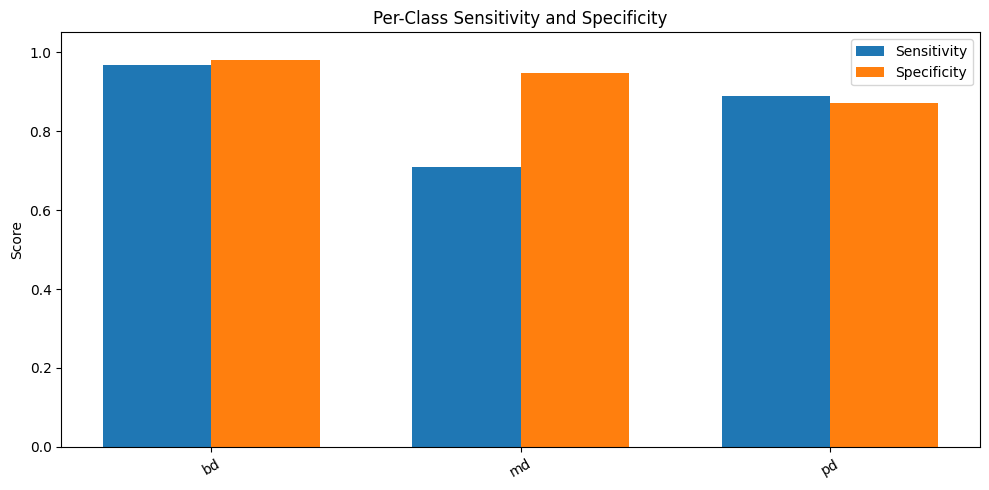

In [ ]:
plot_sensitivity_specificity(results)


In [ ]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize


In [ ]:
def compute_roc_auc(model, loader, num_classes):
    model.eval()

    all_probs = []
    all_labels = []

    with torch.no_grad():
        for bags, labels, ids in loader:
            bag = bags[0].to(device)
            labels = labels.to(device)

            bag_logits, _ = model(bag)
            probs = torch.softmax(bag_logits, dim=1)

            all_probs.append(probs.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    all_probs = np.vstack(all_probs)
    all_labels = np.concatenate(all_labels)

    bin_labels = label_binarize(all_labels, classes=list(range(num_classes)))

    roc_auc = {}
    for i, cls in enumerate(le.classes_):
        roc_auc[cls] = roc_auc_score(bin_labels[:, i], all_probs[:, i])

    return roc_auc


In [ ]:
roc_auc = compute_roc_auc(model, test_loader, num_classes=len(le.classes_))

print("\n📈 ROC-AUC Per Class")
for k, v in roc_auc.items():
    print(f"{k:15s}: {v:.4f}")



📈 ROC-AUC Per Class
bd             : 0.9987
md             : 0.9510
pd             : 0.9657


In [ ]:
def get_fp_fn_samples(model, loader):
    model.eval()
    fp, fn = [], []

    with torch.no_grad():
        for bags, labels, ids in loader:
            bag = bags[0].to(device)
            labels = labels.to(device)

            logits, inst_logits = model(bag)
            preds = logits.argmax(1)

            y_true = labels.item()
            y_pred = preds.item()

            if y_pred != y_true:
                if y_pred > y_true:
                    fp.append((bags[0], y_true, y_pred, ids[0]))
                else:
                    fn.append((bags[0], y_true, y_pred, ids[0]))

    return fp, fn


In [ ]:
def visualize_mil_attention(bag, inst_logits, title="MIL Attention"):
    attn = torch.softmax(inst_logits.squeeze(), dim=0).cpu().numpy()

    plt.figure(figsize=(12, 2))
    plt.bar(range(len(attn)), attn)
    plt.title(title)
    plt.xlabel("Patch Index")
    plt.ylabel("Attention Weight")
    plt.show()
